#1. Load CSV & Ambil 5.000 Sampel Produk Asli

In [ ]:
import numpy as np
import pandas as pd

# Load dataset asli dari file CSV yang diunggah
df_raw = pd.read_csv('data_products_id_small.csv')

# Drop kolom image yang tidak diperlukan
if 'image' in df_raw.columns:
  df_raw = df_raw.drop(columns=['image'])

# Pilih 5 kategori utama populer untuk analisis
top_categories = [
    'Elektronik',
    'Perawatan & Kecantikan',
    'Pakaian Wanita',
    'Perlengkapan Rumah',
    'Makanan & Minuman',
]

# Filter & ambil sampel acak 5.000 baris yang presisi
np.random.seed(42)
df_sample = (
    df_raw[df_raw['main_category'].isin(top_categories)]
    .sample(n=5000, random_state=42)
    .reset_index(drop=True)
)

print(
    f" Sampel 5.000 produk asli berhasil diambil dari {len(df_raw)} baris data!"
)
df_sample['main_category'].value_counts()

 Sampel 5.000 produk asli berhasil diambil dari 162205 baris data!


,count
main_category,
Elektronik,1236
Perawatan & Kecantikan,1179
Perlengkapan Rumah,1005
Pakaian Wanita,989
Makanan & Minuman,591


#2. Feature Enrichment — Generasi Harga, Diskon, & Rating

In [ ]:
n_samples = len(df_sample)

# Logika rentang harga realistis berdasarkan kategori utama Shopee
price_map = {
    'Pakaian Wanita': (25000, 250000),
    'Elektronik': (50000, 3500000),
    'Perawatan & Kecantikan': (15000, 450000),
    'Perlengkapan Rumah': (10000, 850000),
    'Makanan & Minuman': (5000, 150000),
}

locations = [
    'Jakarta Selatan',
    'Jakarta Barat',
    'Kab. Bandung',
    'Kota Surabaya',
    'Kota Medan',
    'Kab. Tangerang',
    'Kota Semarang',
]

original_prices, discounts, prices = [], [], []
for cat in df_sample['main_category']:
  low, high = price_map[cat]
  orig = np.random.randint(low, high)
  disc = np.random.choice(
      [0, 5, 10, 15, 20, 30, 50, 70], p=[0.2, 0.1, 0.2, 0.2, 0.15, 0.08, 0.05, 0.02]
  )
  final_price = int(orig * (1 - disc / 100))
  original_prices.append(orig)
  discounts.append(disc)
  prices.append(final_price)

# Penambahan atribut transaksi ke DataFrame
df_sample['price'] = prices
df_sample['original_price'] = original_prices
df_sample['discount'] = discounts
df_sample['rating'] = np.random.choice(
    [5.0, 4.9, 4.8, 4.7, 4.6, 4.5, 4.0, 3.5, 3.0, 1.0],
    n_samples,
    p=[0.35, 0.25, 0.15, 0.10, 0.05, 0.04, 0.03, 0.015, 0.01, 0.005],
)
df_sample['rating_count'] = np.random.randint(1, 3500, n_samples)
df_sample['review_count'] = (
    df_sample['rating_count'] * np.random.uniform(0.3, 0.7, n_samples)
).astype(int)
df_sample['liked_count'] = (
    df_sample['review_count'] * np.random.uniform(0.5, 2.5, n_samples)
).astype(int)
df_sample['seller_location'] = np.random.choice(locations, n_samples)
df_sample['free_shipping'] = np.random.choice(
    [True, False], n_samples, p=[0.8, 0.2]
)
df_sample['official_shop'] = np.random.choice(
    [True, False], n_samples, p=[0.25, 0.75]
)

print(" Fitur harga, diskon, rating, dan lokasi berhasil ditambahkan!")

 Fitur harga, diskon, rating, dan lokasi berhasil ditambahkan!


#3. Feature Engineering — Potongan Harga & Price Range

In [ ]:
# 1. Potongan Harga (Rupiah)
df_sample['discount_amount'] = (
    df_sample['original_price'] - df_sample['price']
)

# 2. Pengelompokan Rentang Harga (Price Range Bins)
price_bins = [0, 50000, 150000, 500000, 1500000, np.inf]
price_labels = [
    '< Rp50rb',
    'Rp50rb - Rp150rb',
    'Rp150rb - Rp500rb',
    'Rp500rb - Rp1.5Jt',
    '> Rp1.5Jt',
]
df_sample['price_range'] = pd.cut(
    df_sample['price'], bins=price_bins, labels=price_labels, right=False
)

df_sample['price_range'].value_counts().sort_index()


,count
price_range,
< Rp50rb,565
Rp50rb - Rp150rb,1411
Rp150rb - Rp500rb,1657
Rp500rb - Rp1.5Jt,741
> Rp1.5Jt,626


#4. Feature Engineering — Rating Group & Popularity Score

In [ ]:
# 1. Pengelompokan Rating
rating_bins = [0, 3.99, 4.49, 4.79, 5.0]
rating_labels = [
    'Rendah (< 4.0)',
    'Cukup (4.0 - 4.4)',
    'Bagus (4.5 - 4.7)',
    'Sangat Bagus (4.8 - 5.0)',
]
df_sample['rating_group'] = pd.cut(
    df_sample['rating'], bins=rating_bins, labels=rating_labels
)

# 2. Popularity Score Komposit (Skala 0 - 100)
max_review = df_sample['review_count'].max()
max_rating_cnt = df_sample['rating_count'].max()
max_liked = df_sample['liked_count'].max()

df_sample['popularity_score'] = np.round(
    (
        (df_sample['review_count'] / max_review * 40)
        + (df_sample['rating_count'] / max_rating_cnt * 40)
        + (df_sample['liked_count'] / max_liked * 20)
    ),
    2,
)

df_sample[
    ['name', 'main_category', 'price', 'rating', 'popularity_score']
].head()

,name,main_category,price,rating,popularity_score
0,Modul pemantik pemanas Air Gas Water Heater Pu...,Elektronik,1815288,5.0,5.54
1,Van Belt Mesin Jahit Highspeed Industri Jarum ...,Elektronik,1925064,5.0,52.77
2,COD 100% Original MACFEE Maskara 4D Fiber Blac...,Perawatan & Kecantikan,222892,4.9,35.73
3,IP CAMERA CCTV WIFI SPEED DOME PTZ 8MP OUTDOOR...,Elektronik,3147042,4.5,32.68
4,Portable MP3 Player with Bluetooth USB TFT FM ...,Elektronik,830251,4.9,71.95


#5. Categorization — Tipe Toko & Alignment Kolom

In [ ]:
# Labeling tipe toko
df_sample['store_type'] = np.where(
    df_sample['official_shop'], 'Official Mall', 'Star/Regular Seller'
)

# Penyesuaian nama kolom sesuai skema dashboard
df_sample = df_sample.rename(
    columns={
        'name': 'product_name',
        'main_category': 'category',
        'shop_name': 'seller',
    }
)

df_sample['seller'] = df_sample['seller'].fillna('Unbranded / Unknown Shop')

#6. Reorder Kolom & Export File CSV Siap Tableau

In [ ]:
# Penataan urutan kolom standar dashboard
final_columns = [
    'product_id',
    'product_name',
    'category',
    'sub_category',
    'seller',
    'store_type',
    'seller_location',
    'price',
    'original_price',
    'discount',
    'discount_amount',
    'price_range',
    'rating',
    'rating_group',
    'rating_count',
    'review_count',
    'liked_count',
    'popularity_score',
    'free_shipping',
    'official_shop',
]

df_cleaned = df_sample[final_columns]

# Simpan dataset akhir
df_cleaned.to_csv('shopee_cleaned_dataset.csv', index=False)
print(
    ' Dataset akhir berhasil disimpan sebagai: shopee_cleaned_dataset.csv'
)
print(f'Total Baris: {df_cleaned.shape[0]}, Total Kolom: {df_cleaned.shape[1]}')

 Dataset akhir berhasil disimpan sebagai: shopee_cleaned_dataset.csv
Total Baris: 5000, Total Kolom: 20


#7. EDA — Ringkasan Statistik & Distribusi Kategori

In [ ]:
# 1. Ringkasan Statistik Angka (Mean, Min, Max, Median)
print('=== RINGKASAN STATISTIK DESKRIPTIF ===')
display(
    df_cleaned[
        ['price', 'discount', 'rating', 'review_count', 'popularity_score']
    ].describe()
)

# 2. Distribusi Jumlah Produk per Kategori
print('\n=== JUMLAH PRODUK PER KATEGORI ===')
category_counts = df_cleaned['category'].value_counts()
display(category_counts)

=== RINGKASAN STATISTIK DESKRIPTIF ===


,price,discount,rating,review_count,popularity_score
count,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.390860e+05,14.565000,4.783340,867.412600,38.831694
std,7.541622e+05,14.065395,0.418128,550.481772,22.995973
min,2.797000e+03,0.000000,1.000000,0.000000,0.010000
25%,9.651550e+04,5.000000,4.800000,412.000000,19.110000
50%,2.072345e+05,10.000000,4.900000,829.500000,38.200000
75%,5.731738e+05,20.000000,5.000000,1246.000000,57.432500
max,3.490235e+06,70.000000,5.000000,2412.000000,99.580000



=== JUMLAH PRODUK PER KATEGORI ===


,count
category,
Elektronik,1236
Perawatan & Kecantikan,1179
Perlengkapan Rumah,1005
Pakaian Wanita,989
Makanan & Minuman,591


In [ ]:
# Aggregasi rata-rata per kategori
category_insight = (
    df_cleaned.groupby('category')
    .agg(
        total_produk=('product_id', 'count'),
        rata_harga=('price', 'mean'),
        rata_diskon=('discount', 'mean'),
        rata_rating=('rating', 'mean'),
        total_ulasan=('review_count', 'sum'),
        rata_popularity=('popularity_score', 'mean'),
    )
    .reset_index()
)

# Format angka agar mudah dibaca
category_insight['rata_harga'] = category_insight['rata_harga'].map(
    'Rp{:,.0f}'.format
)
category_insight['rata_diskon'] = category_insight['rata_diskon'].map(
    '{:.1f}%'.format
)

print('=== INSIGHT PERFORMA KATEGORI ===')
display(category_insight)

=== INSIGHT PERFORMA KATEGORI ===


,category,total_produk,rata_harga,rata_diskon,rata_rating,total_ulasan,rata_popularity
0,Elektronik,1236,"Rp1,560,610",14.7%,4.780097,1056904,38.295939
1,Makanan & Minuman,591,"Rp67,123",14.7%,4.778342,510758,38.496413
2,Pakaian Wanita,989,"Rp118,191",14.9%,4.796967,878273,39.676168
3,Perawatan & Kecantikan,1179,"Rp199,294",14.3%,4.779135,1014168,38.520212
4,Perlengkapan Rumah,1005,"Rp373,123",14.2%,4.781791,876960,39.222139


/tmp/ipykernel_480/3745685902.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='category', y='price', palette='Set2')


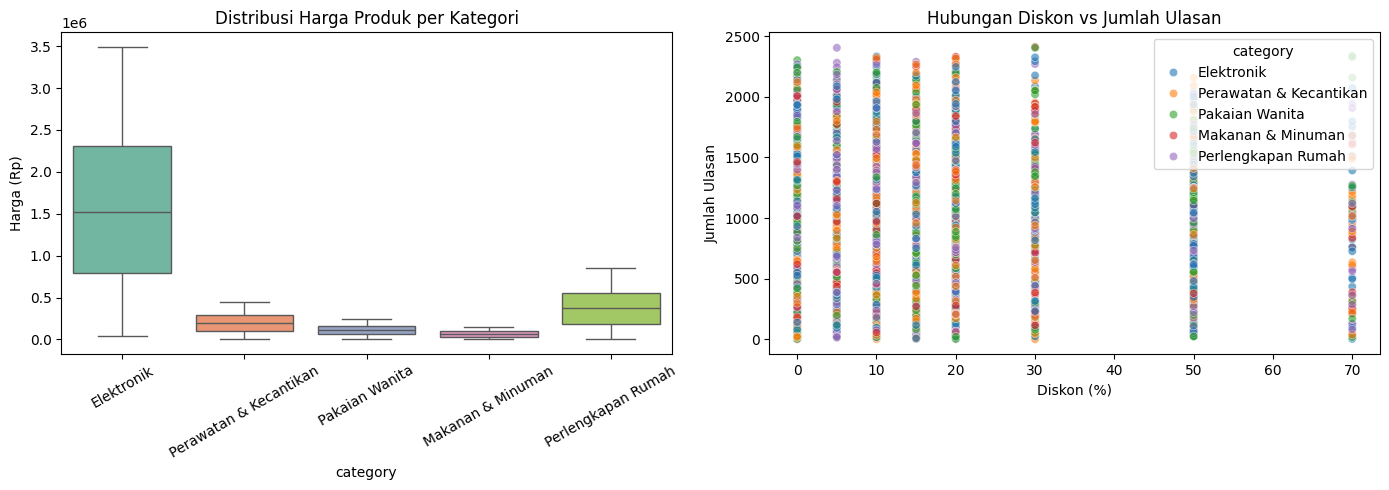

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Chart 1: Distribusi Harga per Kategori
plt.subplot(1, 2, 1)
sns.boxplot(data=df_cleaned, x='category', y='price', palette='Set2')
plt.xticks(rotation=30)
plt.title('Distribusi Harga Produk per Kategori')
plt.ylabel('Harga (Rp)')

# Chart 2: Korelasi Antara Diskon vs Review Count
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df_cleaned,
    x='discount',
    y='review_count',
    hue='category',
    alpha=0.6,
)
plt.title('Hubungan Diskon vs Jumlah Ulasan')
plt.xlabel('Diskon (%)')
plt.ylabel('Jumlah Ulasan')

plt.tight_layout()
plt.show()

In [ ]:
# Cell 10: Export & Download Dataset Akhir
from google.colab import files

# Simpan df_cleaned ke CSV
df_cleaned.to_csv('shopee_cleaned_dataset.csv', index=False)

# Download otomatis ke komputer
files.download('shopee_cleaned_dataset.csv')
print('File shopee_cleaned_dataset.csv berhasil diunduh!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File shopee_cleaned_dataset.csv berhasil diunduh!
